In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statstests.process import stepwise
from scipy.stats import shapiro #teste de Shapiro-Wilk
from scipy import stats #testes estatísticos
from statsmodels.stats.outliers_influence import variance_inflation_factor #diagnóstico de multicolinearidade
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

In [276]:
df = pd.read_excel('dataset.xlsx')  

# Analise Exploratoria

In [277]:
df.head()

,cfab,Modelo do carro,tipo,PM,csd,rc,re,vmvv,HC,co2,mpg
0,20,300C/SRT-8,C,253,4,9.9,3.07,30.9,0.011,288,30.8
1,20,CARAVAN 2WD,T,180,F,9.3,2.49,32.3,0.014,274,32.5
2,20,CROSSFIRE ROADSTER,C,168,R,10.0,3.27,37.1,0.001,250,35.4
3,20,DAKOTA PICKUP 2WD,T,210,R,9.2,3.55,29.6,0.012,316,28.1
4,20,DAKOTA PICKUP 4WD,T,210,4,9.2,3.55,29.6,0.011,365,24.4


In [278]:
df.describe()

,cfab,PM,rc,re,vmvv,HC,co2,mpg
count,21.0,21.000000,20.00000,21.000000,21.000000,21.000000,21.000000,19.000000
mean,20.0,239.476190,9.42000,3.220000,32.400000,0.008476,291.000000,29.389474
std,0.0,103.410163,0.39683,0.503061,5.829494,0.007387,88.754155,5.905825
min,20.0,132.000000,8.60000,2.490000,19.400000,0.000000,0.000000,18.700000
25%,20.0,168.000000,9.20000,2.690000,29.600000,0.003000,260.000000,25.150000
50%,20.0,210.000000,9.50000,3.070000,32.300000,0.007000,295.000000,28.500000
75%,20.0,249.000000,9.65000,3.550000,36.800000,0.011000,337.000000,33.300000
max,20.0,501.000000,10.00000,4.100000,41.000000,0.024000,474.000000,41.300000


In [279]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cfab             21 non-null     int64  
 1   Modelo do carro  21 non-null     object 
 2   tipo             21 non-null     object 
 3   PM               21 non-null     int64  
 4   csd              21 non-null     object 
 5   rc               20 non-null     float64
 6   re               21 non-null     float64
 7   vmvv             21 non-null     float64
 8   HC               21 non-null     float64
 9   co2              21 non-null     int64  
 10  mpg              19 non-null     float64
dtypes: float64(5), int64(3), object(3)
memory usage: 1.9+ KB


## Dados Ausentes

Existem 2 dados em que a variável dependente **mpg** é nula, portanto para garantir um bom aprendizado supervisionado, será removida

In [280]:
invalid_mpg = df[df['mpg'].isnull()]
df = df.dropna(subset=['mpg'])
print(invalid_mpg)

    cfab       Modelo do carro tipo   PM csd   rc    re  vmvv     HC  co2  mpg
9     20  LIBERTY/CHEROKEE 4WD    T  210   4  9.2  3.73  31.2  0.003  317  NaN
13    20            PT CRUISER    T  220   F  9.5  2.69  37.3  0.002  260  NaN


In [281]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cfab             19 non-null     int64  
 1   Modelo do carro  19 non-null     object 
 2   tipo             19 non-null     object 
 3   PM               19 non-null     int64  
 4   csd              19 non-null     object 
 5   rc               18 non-null     float64
 6   re               19 non-null     float64
 7   vmvv             19 non-null     float64
 8   HC               19 non-null     float64
 9   co2              19 non-null     int64  
 10  mpg              19 non-null     float64
dtypes: float64(5), int64(3), object(3)
memory usage: 1.8+ KB


O único campo que possui valor nulo é o **rc**. A forma escolhida para resolver este problema foi substituir o valor pela média da coluna

In [282]:
df[df['rc'].isnull()]

,cfab,Modelo do carro,tipo,PM,csd,rc,re,vmvv,HC,co2,mpg
16,20,SEBRING 4-DR,C,200,F,NaN,2.69,36.8,0.011,252,35.1


In [283]:
rc_mean = df[df['rc'].notnull()]['rc'].mean()
rc_mean

np.float64(9.427777777777777)

In [284]:
df.loc[df['rc'].isnull(), 'rc'] = rc_mean

In [285]:
df[df['rc'].isnull()]

,cfab,Modelo do carro,tipo,PM,csd,rc,re,vmvv,HC,co2,mpg


In [286]:
df.loc[16]

cfab                         20
Modelo do carro    SEBRING 4-DR
tipo                          C
PM                          200
csd                           F
rc                     9.427778
re                         2.69
vmvv                       36.8
HC                        0.011
co2                         252
mpg                        35.1
Name: 16, dtype: object

In [287]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cfab             19 non-null     int64  
 1   Modelo do carro  19 non-null     object 
 2   tipo             19 non-null     object 
 3   PM               19 non-null     int64  
 4   csd              19 non-null     object 
 5   rc               19 non-null     float64
 6   re               19 non-null     float64
 7   vmvv             19 non-null     float64
 8   HC               19 non-null     float64
 9   co2              19 non-null     int64  
 10  mpg              19 non-null     float64
dtypes: float64(5), int64(3), object(3)
memory usage: 2.3+ KB


## Dados Incorretos

A variável **co2** possui outlier. A média dos dados é 291, no entanto uma linha possui um valor zerado, o que difere muito. Com o objetivo de minimizar o erro do modelo preditivo, o grupo optou por substituir o valor zerado pela média

In [288]:
df['co2'].describe()

count     19.000000
mean     291.263158
std       93.067384
min        0.000000
25%      257.000000
50%      295.000000
75%      339.500000
max      474.000000
Name: co2, dtype: float64

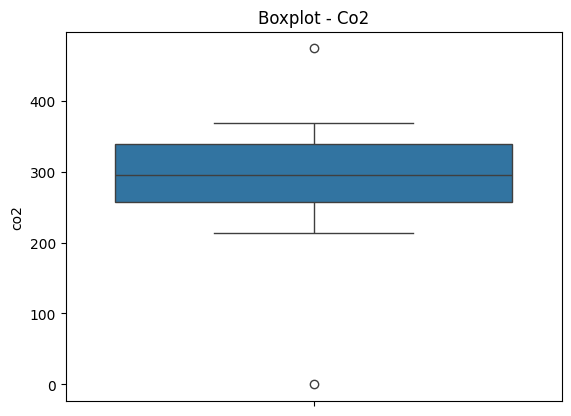

In [289]:
sns.boxplot(y=df["co2"])
plt.title("Boxplot - Co2")
plt.show()

In [290]:
co2_mean = df[df['co2'] != 0]['co2'].mean()
df.loc[df['co2'] == 0, 'co2'] = co2_mean

/var/folders/r_/5frk5sqn49s7hqqttf208d7w0000gn/T/ipykernel_10901/145793349.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '307.44444444444446' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['co2'] == 0, 'co2'] = co2_mean


In [291]:
df[df['co2'] == 0]

,cfab,Modelo do carro,tipo,PM,csd,rc,re,vmvv,HC,co2,mpg


In [292]:
df['co2'].describe()

count     19.000000
mean     307.444444
std       60.718130
min      214.000000
25%      266.000000
50%      307.444444
75%      339.500000
max      474.000000
Name: co2, dtype: float64

In [293]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cfab             19 non-null     int64  
 1   Modelo do carro  19 non-null     object 
 2   tipo             19 non-null     object 
 3   PM               19 non-null     int64  
 4   csd              19 non-null     object 
 5   rc               19 non-null     float64
 6   re               19 non-null     float64
 7   vmvv             19 non-null     float64
 8   HC               19 non-null     float64
 9   co2              19 non-null     float64
 10  mpg              19 non-null     float64
dtypes: float64(6), int64(2), object(3)
memory usage: 2.3+ KB


In [294]:
df.describe()

,cfab,PM,rc,re,vmvv,HC,co2,mpg
count,19.0,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,20.0,242.052632,9.427778,3.221053,32.205263,0.009105,307.444444,29.389474
std,0.0,108.653104,0.403878,0.501131,6.025361,0.007497,60.718130,5.905825
min,20.0,132.000000,8.600000,2.490000,19.400000,0.000000,214.000000,18.700000
25%,20.0,167.500000,9.200000,2.820000,29.300000,0.003500,266.000000,25.150000
50%,20.0,210.000000,9.500000,3.070000,32.300000,0.008000,307.444444,28.500000
75%,20.0,251.000000,9.700000,3.550000,36.800000,0.011500,339.500000,33.300000
max,20.0,501.000000,10.000000,4.100000,41.000000,0.024000,474.000000,41.300000


## Removendo Colunas

Todos os valores da variável **cfab** são identicos pois representam veículos do mesmo fabricante. O grupo optou por remover esta coluna.

Além disso, no modelo de regressão, não é necessário o nome do veículo, logo foi escolhido remove-lo também.

In [295]:
df = df.drop(columns=['Modelo do carro', 'cfab'])

In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tipo    19 non-null     object 
 1   PM      19 non-null     int64  
 2   csd     19 non-null     object 
 3   rc      19 non-null     float64
 4   re      19 non-null     float64
 5   vmvv    19 non-null     float64
 6   HC      19 non-null     float64
 7   co2     19 non-null     float64
 8   mpg     19 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 2.0+ KB


## Dummização

As colunas **tipo** e **csd** representam variáveis qualitativas. Logo deve-se atualizar os dados a partir de variáveis dummy.

In [297]:
df.groupby('tipo').size()

tipo
C     6
T    13
dtype: int64

In [298]:
df.groupby('csd').size()

csd
4    6
F    6
R    7
dtype: int64

Para definir os valores de referência para a nova variável dummizada, consideramos o valor com maior contagem. No caso da variável **tipo**, foi considerado referência veículos do tipo T (caminhão), com 13 aparições. Já no caso da variável **csd**, foi considerado o código R, com 7 aparições.

In [299]:
df = pd.get_dummies(df, columns=['tipo', 'csd'], drop_first=False, dtype=int)
del df['tipo_T']
del df['csd_R']
df.head()

,PM,rc,re,vmvv,HC,co2,mpg,tipo_C,csd_4,csd_F
0,253,9.9,3.07,30.9,0.011,288.0,30.8,1,1,0
1,180,9.3,2.49,32.3,0.014,274.0,32.5,0,0,1
2,168,10.0,3.27,37.1,0.001,250.0,35.4,1,0,0
3,210,9.2,3.55,29.6,0.012,316.0,28.1,0,0,0
4,210,9.2,3.55,29.6,0.011,365.0,24.4,0,1,0


# Modelo de Regressão

In [300]:
df.head()

,PM,rc,re,vmvv,HC,co2,mpg,tipo_C,csd_4,csd_F
0,253,9.9,3.07,30.9,0.011,288.0,30.8,1,1,0
1,180,9.3,2.49,32.3,0.014,274.0,32.5,0,0,1
2,168,10.0,3.27,37.1,0.001,250.0,35.4,1,0,0
3,210,9.2,3.55,29.6,0.012,316.0,28.1,0,0,0
4,210,9.2,3.55,29.6,0.011,365.0,24.4,0,1,0


In [301]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM      19 non-null     int64  
 1   rc      19 non-null     float64
 2   re      19 non-null     float64
 3   vmvv    19 non-null     float64
 4   HC      19 non-null     float64
 5   co2     19 non-null     float64
 6   mpg     19 non-null     float64
 7   tipo_C  19 non-null     int64  
 8   csd_4   19 non-null     int64  
 9   csd_F   19 non-null     int64  
dtypes: float64(6), int64(4)
memory usage: 2.2 KB


In [302]:
# Variáveis independentes
X = df.drop(['mpg'],axis=1)

# Variável dependentes
y = df['mpg']

In [303]:
X.head()

,PM,rc,re,vmvv,HC,co2,tipo_C,csd_4,csd_F
0,253,9.9,3.07,30.9,0.011,288.0,1,1,0
1,180,9.3,2.49,32.3,0.014,274.0,0,0,1
2,168,10.0,3.27,37.1,0.001,250.0,1,0,0
3,210,9.2,3.55,29.6,0.012,316.0,0,0,0
4,210,9.2,3.55,29.6,0.011,365.0,0,1,0


In [304]:
y.head()

0    30.8
1    32.5
2    35.4
3    28.1
4    24.4
Name: mpg, dtype: float64

In [305]:
model=(sm.OLS(y,sm.add_constant(X)).fit())
model.summary(title='Sumario')

/Users/andrade/www/study/tcd-proj1/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                   Sumario                                    
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     41.88
Date:                Sat, 16 May 2026   Prob (F-statistic):           2.80e-06
Time:                        22:43:21   Log-Likelihood:                -24.484
No. Observations:                  19   AIC:                             68.97
Df Residuals:                       9   BIC:                             78.41
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.3175      9.344      2.709      0.024       4.179      46.455
PM            -0.0220      0.008     -2.908      0.017      -0.039      -0.005
rc             1.8939      1.128      1.680      0.127      -0.657       4.445
re            -1.1767      1.674     -0.703      0.500      -4.963       2.609
vmvv           0.0581      0.173      0.335      0.745      -0.334       0.450
HC            13.9079     54.518      0.255      0.804    -109.420     137.236
co2           -0.0228      0.014     -1.682      0.127      -0.053       0.008
tipo_C         3.4992      1.072      3.263      0.010       1.073       5.925
csd_4         -3.0931      0.790     -3.913      0.004      -4.881      -1.305
csd_F          0.6716      1.361      0.494      0.633      -2.407       3.750
==============================================================================
Omnibus:                        0.204   Durbin-Watson:                   2.020
Prob(Omnibus):                  0.903   Jarque-Bera (JB):                0.386
Skew:                           0.166   Prob(JB):                        0.824
Kurtosis:                       2.386   Cond. No.                     7.57e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.57e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

O primeiro modelo obtido foi:
`mpg = -0.0220*PM + 1.8939*rc - 1.1767*re + 0.0581*vmvv + 13.9079*HC - 0.0228*co2 + 3.4992*tipo_C - 3.0931*csd_4 + 0.6716*csd_F`

Analisando a tabela, chegamos as seguintes conclusões sobre o modelo:

- O coeficiente de determinação é de 0.977, isto é, 97.7% da variação da variável **mpg** é respondida pela variação das variáveis dependentes.

- O Prob(F-statistic) é de 2.80e-06. Como o valor é < 0.05, o modelo é significativo. Isto é, ao menos um dos parâmetros beta são significativos.

In [306]:
model_confs = model.conf_int(alpha=0.05)
model_confs.columns = ['lower_bound', 'upper_bound']
model_confs

,lower_bound,upper_bound
const,4.179450,46.455461
PM,-0.039181,-0.004892
rc,-0.656653,4.444514
re,-4.962517,2.609166
vmvv,-0.333955,0.450222
HC,-109.420165,137.236058
co2,-0.053382,0.007854
tipo_C,1.073406,5.924952
csd_4,-4.881356,-1.304927
csd_F,-2.406838,3.749993


In [307]:
print("Intervalo de confiança de 95% para os coeficientes do modelo:")
not_significant = []
for conf in model_confs.itertuples():
    print(f"{conf.Index}: [{conf[1]:.4f}, {conf[2]:.4f}] -> {'Significativo' if conf[1] > 0 or conf[2] < 0 else 'Não significativo'}")
    if conf[1] <= 0 and conf[2] >= 0:
        not_significant.append(conf.Index)

Intervalo de confiança de 95% para os coeficientes do modelo:
const: [4.1794, 46.4555] -> Significativo
PM: [-0.0392, -0.0049] -> Significativo
rc: [-0.6567, 4.4445] -> Não significativo
re: [-4.9625, 2.6092] -> Não significativo
vmvv: [-0.3340, 0.4502] -> Não significativo
HC: [-109.4202, 137.2361] -> Não significativo
co2: [-0.0534, 0.0079] -> Não significativo
tipo_C: [1.0734, 5.9250] -> Significativo
csd_4: [-4.8814, -1.3049] -> Significativo
csd_F: [-2.4068, 3.7500] -> Não significativo


Com relação aos parâmetros, chegamos as seguintes conclusões:
- PM: O valor P>|t| é < 0.05, logo **é significativo**
- rc: O valor P>|t| é > 0.05, logo **não é significativo**
- re: O valor P>|t| é > 0.05, logo **não é significativo**
- vmvv: O valor P>|t| é > 0.05, logo **não é significativo**
- HC: O valor P>|t| é > 0.05, logo **não é significativo**
- co2: O valor P>|t| é > 0.05, logo **não é significativo**
- tipo_C: O valor P>|t| é < 0.05, logo **é significativo**
- csd_4: O valor P>|t| é < 0.05, logo **é significativo**
- csd_F: O valor P>|t| é > 0.05, logo **não é significativo**

## Procedimento Step Wise


In [308]:
stepwise_model = stepwise(model, pvalue_limit=0.05)

# Parâmetros do 'stepwise_model' (output já obtido no código anterior)
stepwise_model.summary()

Regression type: OLS 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('re') + Q('vmvv') + Q('HC') + Q('co2') + Q('tipo_C') + Q('csd_4') + Q('csd_F')

 Discarding atribute "Q('HC')" with p-value equal to 0.8043739032128674 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('re') + Q('vmvv') + Q('co2') + Q('tipo_C') + Q('csd_4') + Q('csd_F')

 Discarding atribute "Q('csd_F')" with p-value equal to 0.6572804519262093 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('re') + Q('vmvv') + Q('co2') + Q('tipo_C') + Q('csd_4')

 Discarding atribute "Q('vmvv')" with p-value equal to 0.38302858152154895 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('re') + Q('co2') + Q('tipo_C') + Q('csd_4')

 Discarding atribute "Q('re')" with p-value equal to 0.06633014909755308 

Estimating model...: 
 mpg ~ Q('PM') + Q('rc') + Q('co2') + Q('tipo_C') + Q('csd_4')

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('HC')", 'p-value': np.fl

/Users/andrade/www/study/tcd-proj1/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     72.67
Date:                Sat, 16 May 2026   Prob (F-statistic):           4.89e-09
Time:                        22:43:21   Log-Likelihood:                -28.216
No. Observations:                  19   AIC:                             68.43
Df Residuals:                      13   BIC:                             74.10
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      22.7394      8.413      2.703      0.018       4.565      40.914
Q('PM')        -0.0236      0.005     -4.704      0.000      -0.034      -0.013
Q('rc')         2.3671      0.878      2.697      0.018       0.471       4.264
Q('co2')       -0.0323      0.010     -3.092      0.009      -0.055      -0.010
Q('tipo_C')     3.3542      0.973      3.448      0.004       1.253       5.456
Q('csd_4')     -3.3862      0.695     -4.875      0.000      -4.887      -1.886
==============================================================================
Omnibus:                        0.151   Durbin-Watson:                   2.247
Prob(Omnibus):                  0.927   Jarque-Bera (JB):                0.306
Skew:                          -0.170   Prob(JB):                        0.858
Kurtosis:                       2.480   Cond. No.                     1.16e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [309]:
print(f"Dos {len(model.params)} parâmetros do modelo original, {len(not_significant)} foram declarados não signficativos e preparados para remoção no stepwise.")
print("No entanto, os seguintes parâmetros se tornaram significativos após o processo stepwise:")
for param in stepwise_model.params.index:
    param = param.replace("Q('", '').replace("')", '')
    if param in not_significant:
        print(f"- Parâmetro '{param}' se tornou significativo.")

Dos 10 parâmetros do modelo original, 6 foram declarados não signficativos e preparados para remoção no stepwise.
No entanto, os seguintes parâmetros se tornaram significativos após o processo stepwise:
- Parâmetro 'rc' se tornou significativo.
- Parâmetro 'co2' se tornou significativo.


## Testes

### Normalidade dos resíduos

In [310]:
# Teste de Shapiro-Wilk (já que o tamanho da amostra é menor que 30)
stat, p = shapiro(stepwise_model.resid)

# Interpretação
print('Statistics=%.5f, p-value=%.4f' % (stat, p))
alpha = 0.05 #nível de significância
if p > alpha:
	print('Não se rejeita H0')
else:
	print('Rejeita-se H0')

Statistics=0.98056, p-value=0.9486
Não se rejeita H0


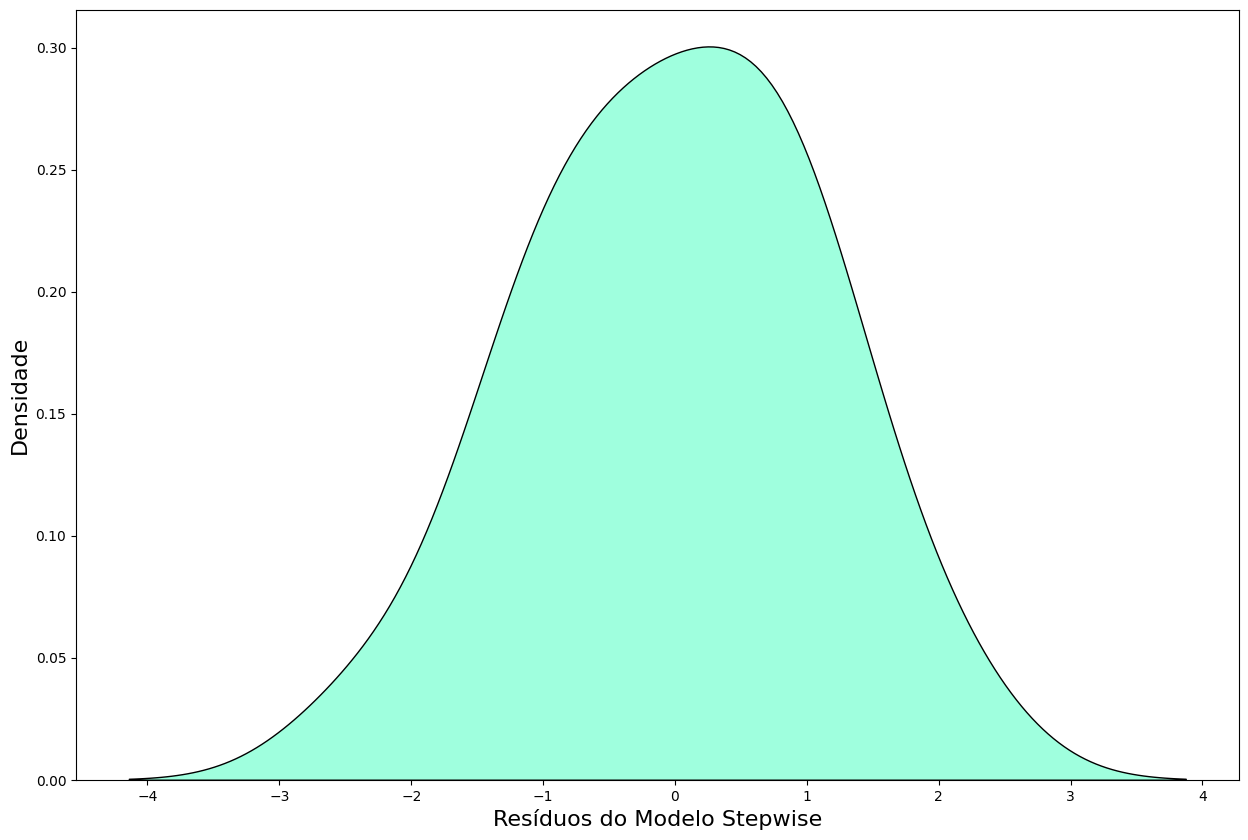

In [311]:
plt.figure(figsize=(15,10))
sns.kdeplot(data=stepwise_model.resid, multiple="stack",
            color='aquamarine')
plt.xlabel('Resíduos do Modelo Stepwise', fontsize=16)
plt.ylabel('Densidade', fontsize=16)
plt.show()

### Multicolinearidade

#### Modelo Completo

In [312]:
X1 = df.drop(columns='mpg')

X1 = sm.add_constant(X1)

vif1 = pd.Series(
    [variance_inflation_factor(X1.values, i)
     for i in range(X1.shape[1])],
    index=X1.columns
)

tolerance1 = 1 / vif1

vif_tolerance = pd.concat([vif1, tolerance1],
          axis=1,
          keys=['VIF', 'Tolerance'])
vif_tolerance

,VIF,Tolerance
const,1019.785116,0.000981
PM,7.502896,0.133282
rc,2.294451,0.435834
re,7.782637,0.128491
vmvv,12.067964,0.082864
HC,1.848593,0.540952
co2,7.473076,0.133814
tipo_C,2.901805,0.344613
csd_4,1.576911,0.634151
csd_F,4.673288,0.213982


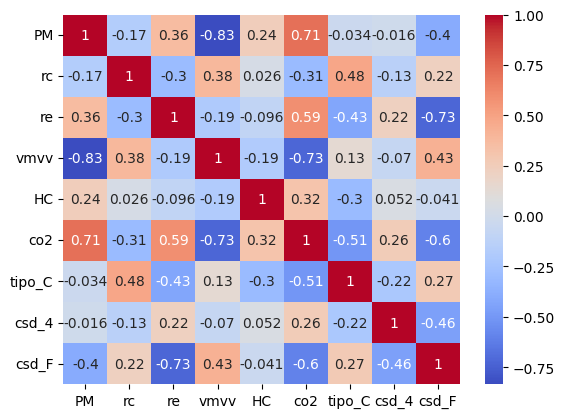

In [313]:
corr = X1.drop(columns='const').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [314]:
print("Variáveis com possível multicolinearidade (VIF):\n")

for variavel, valor in vif1.items():

    if variavel != 'const':

        if valor > 10:
            nivel = "SEVERA"

        elif valor > 5:
            nivel = "MODERADA/ALTA"

        else:
            continue

        print(f"{variavel}: VIF = {valor:.2f} --> {nivel}")

Variáveis com possível multicolinearidade (VIF):

PM: VIF = 7.50 --> MODERADA/ALTA
re: VIF = 7.78 --> MODERADA/ALTA
vmvv: VIF = 12.07 --> SEVERA
co2: VIF = 7.47 --> MODERADA/ALTA


#### Modelo após step wise

In [315]:
X2 = df[['PM', 'rc', 'co2', 'tipo_C', 'csd_4']]
X2 = sm.add_constant(X2)

vif2 = pd.Series(
    [variance_inflation_factor(X2.values, i)
     for i in range(X2.shape[1])],
    index=X2.columns
)

tolerance2 = 1 / vif2
vif_tolerance2 = pd.concat([vif2, tolerance2], axis=1, keys=['VIF', 'Tolerance'])
vif_tolerance2

,VIF,Tolerance
const,806.099756,0.001241
PM,3.206888,0.311829
rc,1.356255,0.737324
co2,4.353492,0.229701
tipo_C,2.328272,0.429503
csd_4,1.187266,0.842271


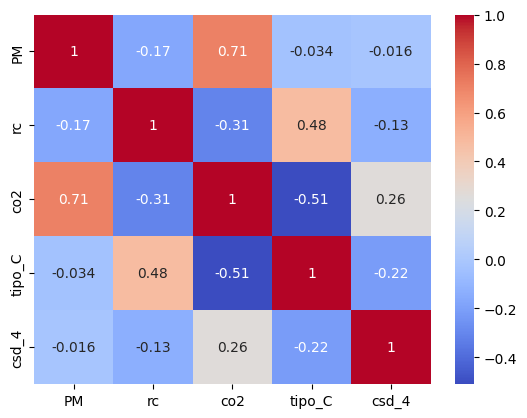

In [316]:
corr = X2.drop(columns='const').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [317]:
print("Variáveis com possível multicolinearidade (VIF):\n")

for variavel, valor in vif2.items():

    if variavel != 'const':

        if valor > 10:
            nivel = "SEVERA"

        elif valor > 5:
            nivel = "MODERADA/ALTA"

        else:
            continue

        print(f"{variavel}: VIF = {valor:.2f} --> {nivel}")

Variáveis com possível multicolinearidade (VIF):



### Heterocedasticidade

In [318]:
# Teste de Breusch-Pagan/Cook-Weisberg para diagnóstico de heterocedasticidade

# Criação de função 'breusch_pagan_test' para o teste de Breusch-Pagan para
#a elaboração de diagnóstico de heterocedasticidade


def breusch_pagan_test(modelo):

    df = pd.DataFrame({'yhat':modelo.fittedvalues,
                       'resid':modelo.resid})

    df['up'] = (np.square(df.resid))/np.sum(((np.square(df.resid))/df.shape[0]))

    modelo_aux = sm.OLS.from_formula('up ~ yhat', df).fit()

    anova_table = sm.stats.anova_lm(modelo_aux, typ=2)

    anova_table['sum_sq'] = anova_table['sum_sq']/2

    chisq = anova_table['sum_sq'].iloc[0]

    p_value = 1 - stats.chi2.cdf(chisq, 1)

    print(f"chisq: {chisq}")

    print(f"p-value: {p_value}")

    return chisq, p_value

#### Modelo Completo

In [319]:
# Teste de Breusch-Pagan propriamente dito

stat, p = breusch_pagan_test(model)

# H0 do teste: ausência de heterocedasticidade no modelo estimado
# H1 do teste: existência de heterocedasticidade no modelo estimado

# Interpretação
print('Statistics=%.6f, p-value=%.7f' % (stat, p))
alpha = 0.05 #nível de significância
if p > alpha:
	print('Não se rejeita H0')
else:
	print('Rejeita-se H0')

chisq: 3.972950420547908
p-value: 0.046236690640189426
Statistics=3.972950, p-value=0.0462367
Rejeita-se H0


Após aplicar o teste de Breusch-Pagan no modelo completo, o p-value obtido é de 0.0462, menor que 5%. Logo rejeita-se a hipótese nula, indicando a presença de heterocedasticidade nos resíduos do modelo.

#### Modelo após step wise

In [320]:
# Teste de Breusch-Pagan propriamente dito

stat, p = breusch_pagan_test(stepwise_model)

# H0 do teste: ausência de heterocedasticidade no modelo estimado
# H1 do teste: existência de heterocedasticidade no modelo estimado

# Interpretação
print('Statistics=%.6f, p-value=%.7f' % (stat, p))
alpha = 0.05 #nível de significância
if p > alpha:
	print('Não se rejeita H0')
else:
	print('Rejeita-se H0')

chisq: 2.494660481581125
p-value: 0.11423300861817609
Statistics=2.494660, p-value=0.1142330
Não se rejeita H0


Após aplicar o teste de Breusch-Pagan no modelo após o procedimento stepwise, o p-value obtido é de 0.1142, maior que 5%. Logo não rejeita a hipótese nula e indica que a nova seleção de variáveis contribuiu significamente nas propriedades do modelo.

## Conclusão

In [321]:
stepwise_model.summary(title='Sumário do modelo final após stepwise')

/Users/andrade/www/study/tcd-proj1/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                    Sumário do modelo final após stepwise                     
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     72.67
Date:                Sat, 16 May 2026   Prob (F-statistic):           4.89e-09
Time:                        22:43:22   Log-Likelihood:                -28.216
No. Observations:                  19   AIC:                             68.43
Df Residuals:                      13   BIC:                             74.10
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      22.7394      8.413      2.703      0.018       4.565      40.914
Q('PM')        -0.0236      0.005     -4.704      0.000      -0.034      -0.013
Q('rc')         2.3671      0.878      2.697      0.018       0.471       4.264
Q('co2')       -0.0323      0.010     -3.092      0.009      -0.055      -0.010
Q('tipo_C')     3.3542      0.973      3.448      0.004       1.253       5.456
Q('csd_4')     -3.3862      0.695     -4.875      0.000      -4.887      -1.886
==============================================================================
Omnibus:                        0.151   Durbin-Watson:                   2.247
Prob(Omnibus):                  0.927   Jarque-Bera (JB):                0.306
Skew:                          -0.170   Prob(JB):                        0.858
Kurtosis:                       2.480   Cond. No.                     1.16e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Análise de Componentes Principais

## Definição dos componentes

In [322]:
pca = PCA()
pca_result = pca.fit_transform(scale(df))
pca_result_df = pd.DataFrame(
    pca_result,
    columns=[f'cp{i+1}' for i in range(pca_result.shape[1])]
)
pca_result_df.head()

,cp1,cp2,cp3,cp4,cp5,cp6,cp7,cp8,cp9,cp10
0,0.374815,0.250426,-1.171714,1.994163,0.946739,-0.346743,0.031479,0.000493,-0.243788,-0.012842
1,1.457272,0.612709,1.886372,-0.647176,0.429548,0.315466,-0.254330,-0.143767,-0.058866,-0.010803
2,2.112207,-0.193437,-1.930524,0.523905,-0.822529,-0.404988,-0.538159,-0.012167,0.089516,-0.197017
3,-0.904946,-0.264860,0.405367,-0.570644,-0.675768,-0.622242,-0.579416,0.008608,-0.342423,-0.130649
4,-1.906587,-1.124641,0.256020,0.508265,0.629690,0.150262,-0.042573,0.472945,-0.262775,-0.037146


In [323]:
pca.components_

array([[-0.33217071,  0.23271653, -0.32074602,  0.34317164, -0.12372672,
        -0.42420586,  0.45186201,  0.25777869, -0.17478938,  0.34412422],
       [ 0.49303776,  0.18961043, -0.32039536, -0.43699667,  0.25742581,
         0.11879583,  0.02353161,  0.34728035, -0.42199745,  0.21845513],
       [-0.1851038 , -0.21755383, -0.27760066,  0.0877172 ,  0.65161336,
         0.04255109, -0.0395107 , -0.53839797, -0.05613533,  0.33564159],
       [-0.00195609,  0.65216439, -0.06569418,  0.14080032,  0.46066495,
         0.07678041, -0.00400611,  0.15526633,  0.50006205, -0.24133829],
       [-0.03018715, -0.38396249, -0.51657558, -0.30966641, -0.12120516,
        -0.12583344, -0.06702142,  0.22497885,  0.62753872,  0.0973703 ],
       [ 0.0487042 ,  0.4494705 , -0.14583971, -0.05355121, -0.47757989,
         0.33199864, -0.16742639, -0.38574023,  0.15061584,  0.48337285],
       [ 0.40512772, -0.17087816,  0.40511377,  0.38576755,  0.13104439,
        -0.08868776, -0.15074379,  0.26915636

## Análise dos componentes

In [324]:
print("Explicação da variância por componente principal:")
pca.explained_variance_ratio_

Explicação da variância por componente principal:


array([0.47165652, 0.15141679, 0.12006794, 0.10222744, 0.07678328,
       0.03690656, 0.02404996, 0.01157291, 0.00368853, 0.00163007])

In [325]:
print("Explicação acumulada da variância por componente principal:")
np.cumsum(np.round(pca.explained_variance_ratio_,decimals=4)*100)

Explicação acumulada da variância por componente principal:


array([ 47.17,  62.31,  74.32,  84.54,  92.22,  95.91,  98.31,  99.47,
        99.84, 100.  ])

O gráfico abaixo mostra quantos componentes seriam necessários para variância explicada acumulada de 90%.
A partir da análise do gráfico, pode-se concluir que para uma variância acima de 90%, garantindo um bom equilibrio entre dimensionalidade do modelo e precisão nos resultados, seria necessário **5 componentes**.

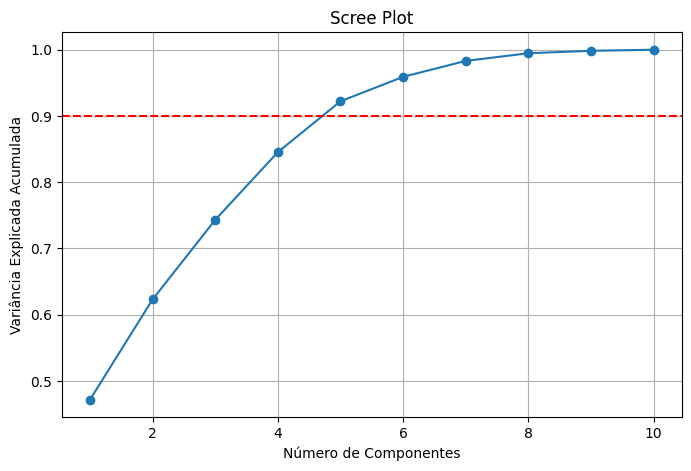

In [326]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative)+1),
         cumulative,
         marker='o')

plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Scree Plot')

plt.axhline(y=0.90, color='r', linestyle='--')
plt.grid(True)

plt.show()

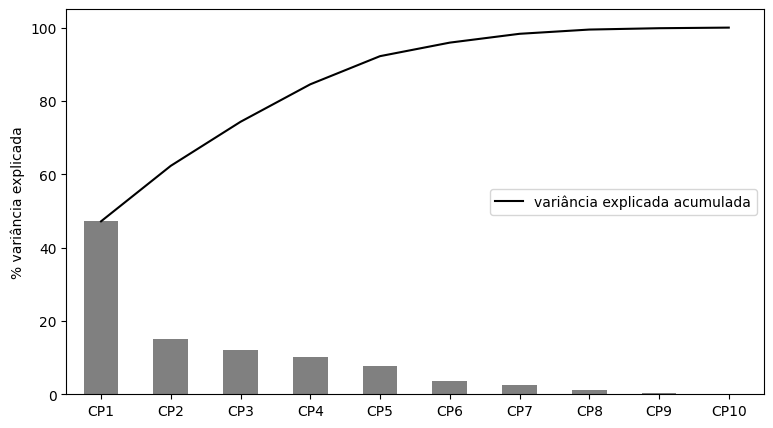

In [327]:
#Gráfico da variância acumulada
# variâncias acumuladas
tot = sum(pca.explained_variance_)
var_exp = [(i / tot)*100 for i in sorted(pca.explained_variance_, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
# número de CPs gerados (k = p)
cp =['CP'+str(i+1) for i in range(len(pca.components_))]
# dataframe com as variâncias acumuladas para criar o scree plot
df_plot = pd.DataFrame({'cp': cp, 'var_exp': var_exp, 'cum_var_exp': cum_var_exp})
# scree plot com %
fig, ax = plt.subplots(figsize=(9,5))
df_plot.plot.bar('cp', 'var_exp', color='gray', ax=ax, legend=False)
df_plot.plot.line('cp', 'cum_var_exp', color='black', ax=ax)
plt.legend(labels=['variância explicada acumulada'],
           loc='center right',)
plt.ylabel('% variância explicada')
plt.xlabel('');

## Interpretação dos componentes

In [332]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'CP{i+1}' for i in range(pca.n_components_)],
    index=df.columns
)

components = loadings.iloc[:, :5]

print(np.round(loadings.iloc[:, :5], 3))

          CP1    CP2    CP3    CP4    CP5
PM     -0.332  0.493 -0.185 -0.002 -0.030
rc      0.233  0.190 -0.218  0.652 -0.384
re     -0.321 -0.320 -0.278 -0.066 -0.517
vmvv    0.343 -0.437  0.088  0.141 -0.310
HC     -0.124  0.257  0.652  0.461 -0.121
co2    -0.424  0.119  0.043  0.077 -0.126
mpg     0.452  0.024 -0.040 -0.004 -0.067
tipo_C  0.258  0.347 -0.538  0.155  0.225
csd_4  -0.175 -0.422 -0.056  0.500  0.628
csd_F   0.344  0.218  0.336 -0.241  0.097


In [337]:
for component in components.columns:
    print(f"Componente {component}:")
    sorted_loadings = components[component].abs().sort_values(ascending=False)
    for variable in sorted_loadings.index:
        loading_value = components.loc[variable, component]
        if abs(loading_value) > 0.3:  # Considerando apenas loadings significativos
            print(f"  {variable}: {loading_value:.3f}")

Componente CP1:
  mpg: 0.452
  co2: -0.424
  csd_F: 0.344
  vmvv: 0.343
  PM: -0.332
  re: -0.321
Componente CP2:
  PM: 0.493
  vmvv: -0.437
  csd_4: -0.422
  tipo_C: 0.347
  re: -0.320
Componente CP3:
  HC: 0.652
  tipo_C: -0.538
  csd_F: 0.336
Componente CP4:
  rc: 0.652
  csd_4: 0.500
  HC: 0.461
Componente CP5:
  csd_4: 0.628
  re: -0.517
  rc: -0.384
  vmvv: -0.310
